In [1]:
!pip install torchinfo

In [2]:

import os
import re
import cv2
import time
import glob
import random
import shutil
import platform
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
from tabulate import tabulate
from tqdm import tqdm, notebook
from PIL import Image, ImageOps
import PIL
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
from torchvision import transforms, datasets, models
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    ColorJitter, RandomRotation, RandomResizedCrop
)
from torchvision.transforms.functional import gaussian_blur

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from torchinfo import summary


In [3]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB


In [4]:
seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [5]:
import re
import shutil
import pandas as pd
from pathlib import Path


CSV_PATH = Path("/kaggle/input/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Define valid AQI bins only (no Unknown)
AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)


df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"

fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)
df["level"] = df["pm25_bin"].apply(bin_to_label)

# Drop rows where level is None (invalid/unknown bins)
df = df.dropna(subset=["level"])

print("Class counts:")
print(df["level"].value_counts(dropna=False))

# Create only valid label folders
for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0
valid_labels = {b[2] for b in AQI_BINS}

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    if row["level"] not in valid_labels:
        continue

    dst = OUT_DIR / row["level"] / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")


Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset


In [6]:
TEST_CSV_PATH = Path("/kaggle/input/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/pm25vision/test/images")
OUT_DIR       = Path("/kaggle/working/dataset") 


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str | None:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  # no "Unknown"

def bin_to_label(bin_val) -> str | None:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None  # no "Unknown"
    lo = int(m.group(1))
    return aqi_to_label(lo)


df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)

missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue

    # skip any rows that didn't map to a valid label
    if r["level"] not in valid_labels:
        continue

    dest_dir = OUT_DIR / r["level"]
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
        # if same file size, skip; else rename to avoid clobbering
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST merge complete.")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Merged into: {OUT_DIR}")


✅ TEST merge complete.
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Merged into: /kaggle/working/dataset


In [7]:
from pathlib import Path
import shutil

OUT_DIR = Path("/kaggle/working/dataset")


unknown_dir = OUT_DIR / "Unknown"
if unknown_dir.exists() and unknown_dir.is_dir():
    shutil.rmtree(unknown_dir)


class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))

print(" Image count per class:\n")

for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")

print("\nTotal images:", sum(class_counts.values()))

 Image count per class:

Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Very_Unhealthy      : 1007

Total images: 11103


In [8]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)

Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/915524645658590.jpg,Good
1,/kaggle/working/dataset/Good/457757988852899.jpg,Good
2,/kaggle/working/dataset/Good/376158418236527.jpg,Good
3,/kaggle/working/dataset/Good/1030770249079840.jpg,Good
4,/kaggle/working/dataset/Good/151098980352622.jpg,Good
5,/kaggle/working/dataset/Good/1641729696576798.jpg,Good
6,/kaggle/working/dataset/Good/374953323870492.jpg,Good
7,/kaggle/working/dataset/Good/2381642591980021.jpg,Good
8,/kaggle/working/dataset/Good/343335478836284.jpg,Good
9,/kaggle/working/dataset/Good/204524171510132.jpg,Good


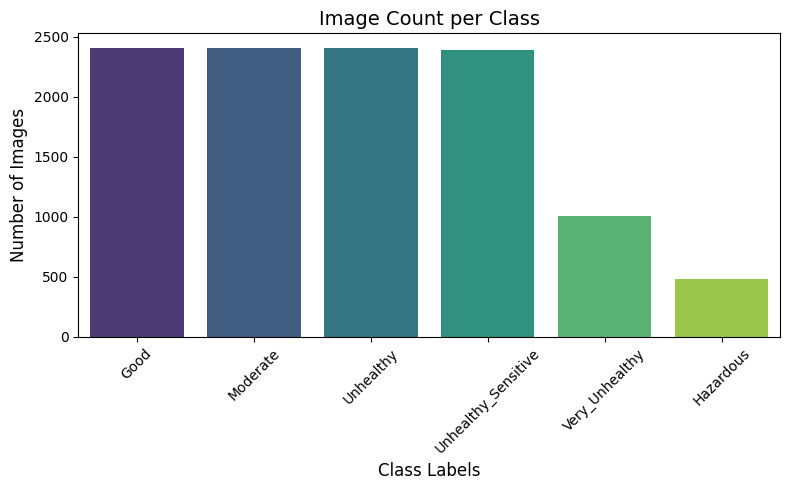

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["label"].value_counts().index,
            y=df["label"].value_counts().values,
            palette="viridis")
plt.title("Image Count per Class", fontsize=14)
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

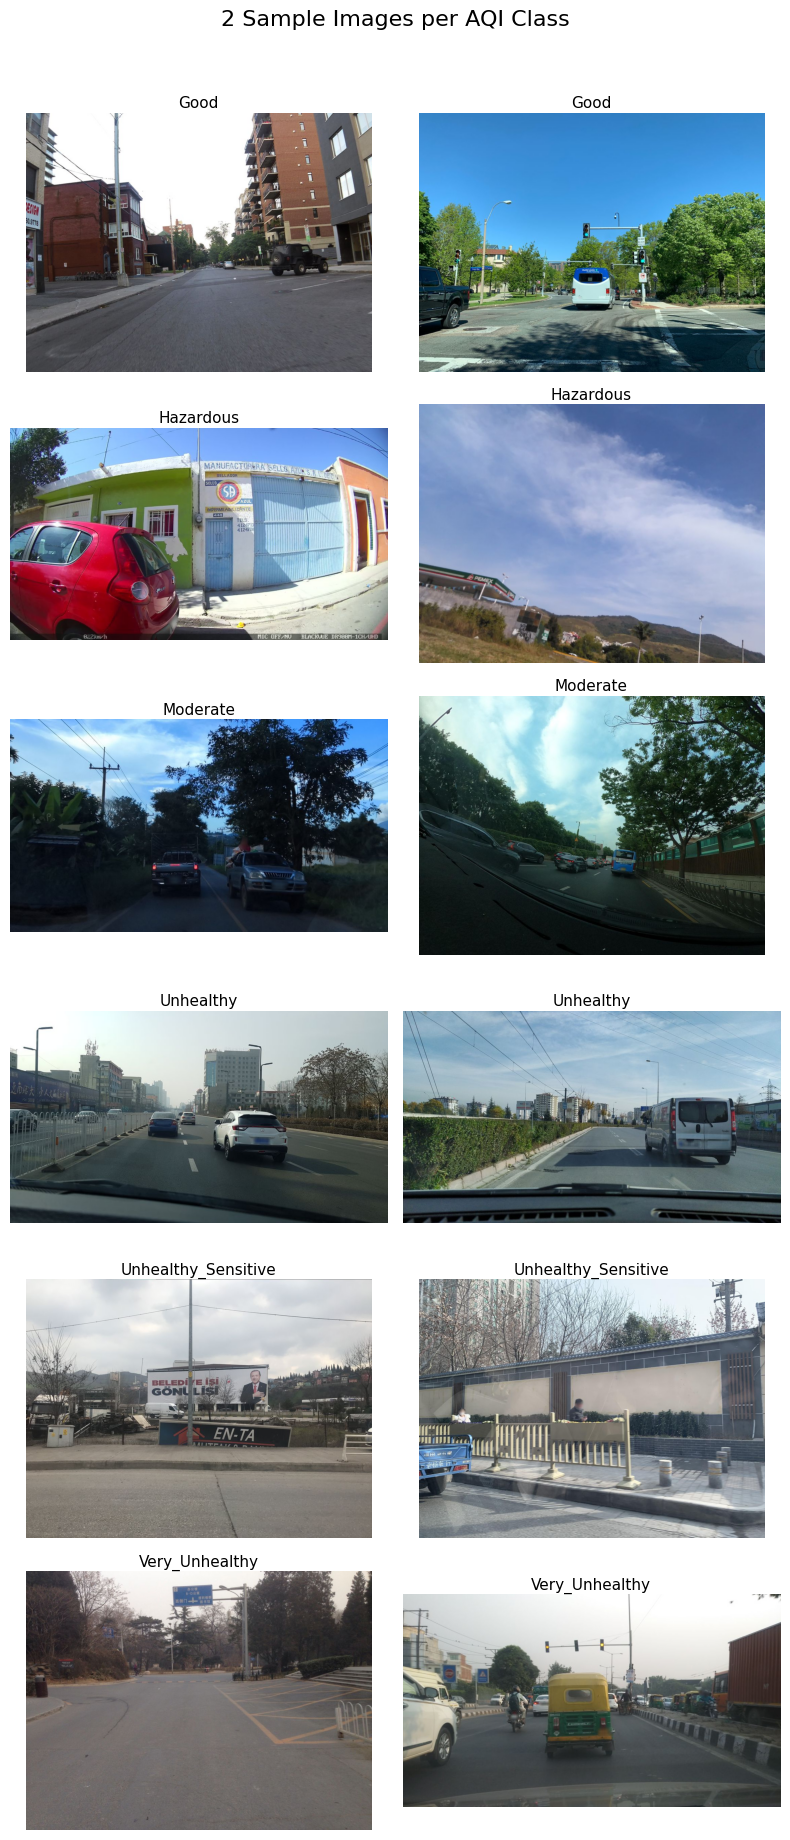

In [10]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
import pandas as pd
from pathlib import Path
import numpy as np
import os


OUT_DIR = Path("/kaggle/working/dataset")

rows = []
for class_dir in sorted([p for p in OUT_DIR.iterdir() if p.is_dir()]):
    label = class_dir.name
    for img_path in class_dir.glob("*"):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(img_path), "label": label})

df = pd.DataFrame(rows)
print(f"✅ Found total {len(df)} images across {df['label'].nunique()} classes.")

RATIOS = [(90,10),(80,20),(70,30),(60,40),(50,50),(40,60),(30,70),(20,80),(10,90)]
RANDOM_STATE = 42


SPLITS = {}  
FIXED_IDX = {} 
all_idx = np.arange(len(df))
labels_all = df["label"].values


for tr, te in RATIOS:
    test_size = te / 100.0

    train_pool_idx, test_idx = train_test_split(
        all_idx,
        test_size=test_size,
        stratify=labels_all,
        random_state=RANDOM_STATE
    )
    FIXED_IDX[(tr, te)] = {
        "train_pool_idx": train_pool_idx,
        "test_idx": test_idx
    }

    # ✅ FIX: added a newline here (was missing before)
    train_pool_df = df.iloc[train_pool_idx].reset_index(drop=True)
    tr_local_idx, va_local_idx = train_test_split(
        np.arange(len(train_pool_df)),
        test_size=0.10,
        stratify=train_pool_df["label"].values,
        random_state=RANDOM_STATE
    )

    train_idx = train_pool_idx[tr_local_idx]
    valid_idx = train_pool_idx[va_local_idx]

    train_df = df.iloc[train_idx].reset_index(drop=True)
    valid_df = df.iloc[valid_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

    SPLITS[(tr, te)] = {
        "train_df": train_df,
        "valid_df": valid_df,
        "test_df":  test_df
    }


print("\n=== Split Summary (counts) ===")
for tr, te in RATIOS:
    s = SPLITS[(tr, te)]
    print(f"{tr}:{te} -> train={len(s['train_df'])}, val={len(s['valid_df'])}, test={len(s['test_df'])}")
print("-------------------------------------------")
print("Total images in dataset: ", len(df))


✅ Found total 11103 images across 6 classes.

=== Split Summary (counts) ===
90:10 -> train=8992, val=1000, test=1111
80:20 -> train=7993, val=889, test=2221
70:30 -> train=6994, val=778, test=3331
60:40 -> train=5994, val=667, test=4442
50:50 -> train=4995, val=556, test=5552
40:60 -> train=3996, val=445, test=6662
30:70 -> train=2997, val=333, test=7773
20:80 -> train=1998, val=222, test=8883
10:90 -> train=999, val=111, test=9993
-------------------------------------------
Total images in dataset:  11103


In [12]:
from tabulate import tabulate

for tr, te in RATIOS:
    s = SPLITS[(tr, te)]
    train_df = s["train_df"]; valid_df = s["valid_df"]; test_df = s["test_df"]

    class_counts_train = train_df['label'].value_counts()
    class_counts_valid = valid_df['label'].value_counts()
    class_counts_test  = test_df['label'].value_counts()

    train_table_data = [[class_name, count] for class_name, count in class_counts_train.items()]
    valid_table_data = [[class_name, count] for class_name, count in class_counts_valid.items()]
    test_table_data  = [[class_name, count]  for class_name, count  in class_counts_test.items()]

    print(f"\n=== {tr}:{te} Split ===")
    print("\n Train Dataset")
    print(tabulate(train_table_data, headers=["Class", "Count"], tablefmt="github"))

    print("\n Validation Dataset")
    print(tabulate(valid_table_data, headers=["Class", "Count"], tablefmt="github"))

    print("\n Test Dataset")
    print(tabulate(test_table_data, headers=["Class", "Count"], tablefmt="github"))



=== 90:10 Split ===

 Train Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |    1950 |
| Unhealthy           |    1949 |
| Moderate            |    1949 |
| Unhealthy_Sensitive |    1939 |
| Very_Unhealthy      |     815 |
| Hazardous           |     390 |

 Validation Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |     217 |
| Moderate            |     217 |
| Unhealthy           |     217 |
| Unhealthy_Sensitive |     215 |
| Very_Unhealthy      |      91 |
| Hazardous           |      43 |

 Test Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |     241 |
| Unhealthy           |     241 |
| Moderate            |     241 |
| Unhealthy_Sensitive |     239 |
| Very_Unhealthy      |     101 |
| Hazardous           |      48 |

=== 80:20 Split ===

 Train Dataset
| Class               |   Count |
|---------------------|---------|
| Good

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
save_root_base = "/kaggle/working/task2_vgg16"
os.makedirs(save_root_base, exist_ok=True)


In [15]:
import PIL.Image
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, dataframe, normalize, is_lb=True):
        """
        Args:
            dataframe : pd.DataFrame containing 'path' and 'label' columns
            normalize : torchvision.transforms to apply to images
            is_lb     : bool, True if labels should be returned
        """
        self.dataframe = dataframe
        self.normalize = normalize
        self.is_lb = is_lb
        
        unique_labels = sorted(self.dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['path']
        image = PIL.Image.open(img_path).convert("RGB")  

        if self.is_lb:
            label = self.label_map[self.dataframe.iloc[index]['label']]
            return self.normalize(image), label
        else:
            return self.normalize(image), self.normalize(image)

In [16]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

train_batch = 32
val_batch = 8

def data_transform(train_df, valid_df, test_df):

    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    normalize = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    train_dataset = ImageDataset(
        train_df,
        normalize,
        is_lb=True
    )

    valid_dataset = ImageDataset(
        valid_df,
        normalize,
        is_lb=True
    )

    test_dataset = ImageDataset(
        test_df,
        normalize,
        is_lb=True
    )

    # ✅ FIX: added newline here before dataloader definitions
    dataloader_train_dataset = DataLoader(
        train_dataset, batch_size=train_batch, shuffle=True, num_workers=2
    )
    dataloader_valid_dataset = DataLoader(
        valid_dataset, batch_size=val_batch, shuffle=False, num_workers=2
    )
    dataloader_test_dataset = DataLoader(
        test_dataset, batch_size=val_batch, shuffle=False, num_workers=2
    )

    return dataloader_train_dataset, dataloader_valid_dataset, dataloader_test_dataset


In [17]:
total_class = len(df['label'].unique())   
learning_rate = 0.0001

# --- VGG16 model ---
model = models.vgg16(pretrained=True)

num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, total_class)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

summary(model, input_size=(train_batch, 3, 224, 224))

try:
    from thop import profile
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "thop"])
    from thop import profile

model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    macs, params = profile(model, inputs=(dummy,), verbose=False)

gmacs  = macs / 1e9
gflops = (2 * macs) / 1e9   # FLOPs ≈ 2 × MACs
mparams = params / 1e6

print(f"[Complexity @224x224]  MACs: {gmacs:.2f} GMACs  (~{gflops:.2f} GFLOPs)  |  Params: {mparams:.2f} M")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 193MB/s]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires rmm-cu12==25.6.*, but you have rmm-cu12 25.2.0 which is incompatible.


[Complexity @224x224]  MACs: 15.47 GMACs  (~30.93 GFLOPs)  |  Params: 134.29 M


In [18]:
start_time_global = time.time()

def train_model(model, criterion, optimizer, dataloader_train_dataset, dataloader_valid_dataset, num_epochs=50, save_path_checkpoints="checkpoints"):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    os.makedirs(save_path_checkpoints, exist_ok=True)

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        epoch_start_time = time.time()  # <-- start timing this epoch
        # Training phase
        model.train()

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        progress_bar = tqdm(enumerate(dataloader_train_dataset), total=len(dataloader_train_dataset))
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            progress_bar.set_description(f"Epoch {epoch+1}/{num_epochs}")
            progress_bar.set_postfix(loss=running_loss / total_train, acc=correct_train / total_train)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        print('Training Loss: {:.3f} Acc: {:.3f}'.format(epoch_train_loss, epoch_train_acc))
# Validation phase
        model.eval()
        running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in dataloader_valid_dataset:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, predicted = torch.max(outputs, 1)
                running_loss += loss.item() * inputs.size(0)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / total_val
        epoch_val_acc = correct_val / total_val
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

        print('Validation Loss: {:.3f} Acc: {:.3f}'.format(epoch_val_loss, epoch_val_acc))

        # <-- end timing this epoch and print it
        epoch_time = time.time() - epoch_start_time
        print(f"Epoch {epoch+1} Time: {epoch_time:.2f} seconds")

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_epoch = epoch + 1
            filepath = f"{save_path_checkpoints}/model.pt"
            checkpoint = {
                "epoch": epoch + 1,
                "model_weight": model.state_dict(),
                "optimizer_state": optimizer.state_dict()
            }
            torch.save(checkpoint, filepath)
            print(f"Best model saved at epoch {best_epoch} with validation accuracy: {best_val_acc:.3f}")

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history
import json
RESULTS_ROWS = []  

for (tr, te) in RATIOS:
    print(f"\n================= Running VGG16 for ratio {tr}:{te} =================")
    
    split = SPLITS[(tr, te)]
    tr_df = split["train_df"]
    va_df = split["valid_df"]
    te_df = split["test_df"]

    # ✅ Loaders
    dataloader_train_dataset, dataloader_valid_dataset, dataloader_test_dataset = data_transform(
        tr_df, va_df, te_df
    )

    # ✅ Model setup
    model_ratio = models.vgg16(pretrained=True)
    num_ftrs = model_ratio.classifier[6].in_features
    model_ratio.classifier[6] = nn.Linear(num_ftrs, len(df['label'].unique()))
    model_ratio = model_ratio.to(device)

    optimizer_ratio = optim.Adam(model_ratio.parameters(), lr=learning_rate)
    criterion_ratio = nn.CrossEntropyLoss()

    # ✅ Checkpoint path
    save_path_checkpoints = os.path.join(save_root_base, f"{tr}_{te}")
    os.makedirs(save_path_checkpoints, exist_ok=True)

    start_time = time.time()

    # ✅ Training
    train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(
        model_ratio, criterion_ratio, optimizer_ratio,
        dataloader_train_dataset, dataloader_valid_dataset,
        num_epochs=50, save_path_checkpoints=save_path_checkpoints
    )

    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training Time [{tr}:{te}]: {training_time:.2f} seconds ---> {training_time/60:.2f} minutes")
    print(f"Average Per-Epoch Time [{tr}:{te}]: {training_time/50:.2f} seconds/epoch")

    # ✅ Save training history
    data_hist = {
        'Epoch': list(range(1, len(train_loss_history) + 1)),
        'Train Loss': train_loss_history,
        'Train Accuracy': train_acc_history,
        'Validation Loss': val_loss_history,
        'Validation Accuracy': val_acc_history
    }
    history = pd.DataFrame(data_hist)
    hist_path = os.path.join(save_path_checkpoints, 'training_data.xlsx')
    history.to_excel(hist_path, index=False)

    RESULTS_ROWS.append({
        "ratio": f"{tr}:{te}",
        "checkpoint_dir": save_path_checkpoints,
        "history_path": hist_path
    })

end_time_global = time.time()
print(f"\n=== All ratios done in {end_time_global - start_time_global:.2f} seconds ===")



================= Running VGG16 for ratio 90:10 =================


Epoch 1/50: 100%|██████████| 281/281 [01:16<00:00,  3.65it/s, acc=0.425, loss=1.34]

Training Loss: 1.335 Acc: 0.425


Validation Loss: 1.134 Acc: 0.521
Epoch 1 Time: 84.78 seconds
Best model saved at epoch 1 with validation accuracy: 0.521


Epoch 2/50: 100%|██████████| 281/281 [01:17<00:00,  3.64it/s, acc=0.593, loss=0.955]

...

Training Loss: 0.000 Acc: 1.000


Validation Loss: 3.053 Acc: 0.505
Epoch 49 Time: 9.98 seconds


Epoch 50/50: 100%|██████████| 32/32 [00:08<00:00,  3.56it/s, acc=1, loss=1.41e-5]

Training Loss: 0.000 Acc: 1.000


Validation Loss: 3.062 Acc: 0.505
Epoch 50 Time: 10.00 seconds
Training Time [10:90]: 537.56 seconds ---> 8.96 minutes
Average Per-Epoch Time [10:90]: 10.75 seconds/epoch

=== All ratios done in 22010.56 seconds ===


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

for (tr, te) in RATIOS:
    save_path_checkpoints = os.path.join("/kaggle/working/task2_efficientnet_b0", f"{tr}_{te}")
    hist_xlsx = os.path.join(save_path_checkpoints, 'training_data.xlsx')
    if not os.path.exists(hist_xlsx):
        print(f"[{tr}:{te}] history file missing at {hist_xlsx}")
        continue

    history = pd.read_excel(hist_xlsx)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['Epoch'], history['Train Loss'], label='Train Loss')
    plt.plot(history['Epoch'], history['Validation Loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss ({tr}:{te})')
    plt.legend(loc='upper right')
    plt.ylim(0, 2)

    plt.subplot(1, 2, 2)
    plt.plot(history['Epoch'], history['Train Accuracy'], label='Train Accuracy')
    plt.plot(history['Epoch'], history['Validation Accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy ({tr}:{te})')
    plt.legend(loc='lower right')
    plt.ylim(0, 1.1)

    plt.tight_layout()
    plot_path = os.path.join(save_path_checkpoints, "curves.png")
    plt.savefig(plot_path)
    plt.show()

[90:10] history file missing at /kaggle/working/task2_efficientnet_b0/90_10/training_data.xlsx
[80:20] history file missing at /kaggle/working/task2_efficientnet_b0/80_20/training_data.xlsx
[70:30] history file missing at /kaggle/working/task2_efficientnet_b0/70_30/training_data.xlsx
[60:40] history file missing at /kaggle/working/task2_efficientnet_b0/60_40/training_data.xlsx
[50:50] history file missing at /kaggle/working/task2_efficientnet_b0/50_50/training_data.xlsx
[40:60] history file missing at /kaggle/working/task2_efficientnet_b0/40_60/training_data.xlsx
[30:70] history file missing at /kaggle/working/task2_efficientnet_b0/30_70/training_data.xlsx
[20:80] history file missing at /kaggle/working/task2_efficientnet_b0/20_80/training_data.xlsx
[10:90] history file missing at /kaggle/working/task2_efficientnet_b0/10_90/training_data.xlsx


In [20]:
import torch
import numpy as np

def evaluate_model(model, criterion, dataloader, return_preds=False):
    """
    Evaluate model on given dataloader.

    Args:
        model: PyTorch model
        criterion: loss function
        dataloader: DataLoader for evaluation
        return_preds: bool, if True returns all predictions and labels (and probs)

    Returns:
        loss: average loss
        accuracy: overall accuracy
        (optional) all_preds, all_labels, all_probs (softmax)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if return_preds:
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

    loss = running_loss / total 
    accuracy = correct / total

    if return_preds:
        return loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)
    else:
        return loss, accuracy

In [21]:
import os
import torch

for (tr, te) in RATIOS:
    print(f"\n[Validation Eval] Ratio {tr}:{te}")
    save_path_checkpoints = os.path.join("/kaggle/working/task2_vgg16", f"{tr}_{te}")
    best_checkpoint_path = f"{save_path_checkpoints}/model.pt"

    # --- VGG16 model for validation ---
    model = models.vgg16(pretrained=True).to(device)
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, len(df['label'].unique()))
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    best_epoch = checkpoint["epoch"]
    model.load_state_dict(checkpoint["model_weight"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])  # optional for evaluation

    split = SPLITS[(tr, te)]
    _, dataloader_valid_dataset, _ = data_transform(split["train_df"], split["valid_df"], split["test_df"])

    best_val_loss, best_val_accuracy = evaluate_model(model, criterion, dataloader_valid_dataset)
    print(f"Best model (from epoch {best_epoch}) - Validation Loss: {best_val_loss:.3f}, Validation Accuracy: {best_val_accuracy:.3f}")



[Validation Eval] Ratio 90:10
Best model (from epoch 42) - Validation Loss: 1.884, Validation Accuracy: 0.661

[Validation Eval] Ratio 80:20
Best model (from epoch 25) - Validation Loss: 1.720, Validation Accuracy: 0.654

[Validation Eval] Ratio 70:30
Best model (from epoch 40) - Validation Loss: 2.409, Validation Accuracy: 0.638

[Validation Eval] Ratio 60:40
Best model (from epoch 14) - Validation Loss: 1.954, Validation Accuracy: 0.618

[Validation Eval] Ratio 50:50
Best model (from epoch 42) - Validation Loss: 1.709, Validation Accuracy: 0.647

[Validation Eval] Ratio 40:60
Best model (from epoch 41) - Validation Loss: 2.188, Validation Accuracy: 0.587

[Validation Eval] Ratio 30:70
Best model (from epoch 30) - Validation Loss: 2.381, Validation Accuracy: 0.586

[Validation Eval] Ratio 20:80
Best model (from epoch 15) - Validation Loss: 3.456, Validation Accuracy: 0.550

[Validation Eval] Ratio 10:90
Best model (from epoch 31) - Validation Loss: 2.642, Validation Accuracy: 0.550



[TEST] Ratio 90:10
Test Loss: 1.926, Test Accuracy: 0.661
Total Test Time: 9.92 seconds for 1111 images
Average Inference Time per Image: 0.008925 s (~8.93 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.531120
1            Hazardous  0.854167
2             Moderate  0.522822
3            Unhealthy  0.825726
4  Unhealthy_Sensitive  0.694561
5       Very_Unhealthy  0.732673

Classification Report:

                     precision    recall  f1-score   support

               Good     0.6214    0.5311    0.5727       241
          Hazardous     0.7455    0.8542    0.7961        48
           Moderate     0.4828    0.5228    0.5020       241
          Unhealthy     0.8257    0.8257    0.8257       241
Unhealthy_Sensitive     0.6484    0.6946    0.6707       239
     Very_Unhealthy     0.8043    0.7327    0.7668       101

           accuracy                         0.6607      1111
          macro avg     0.6880    0.6935    0.6890      1111
     

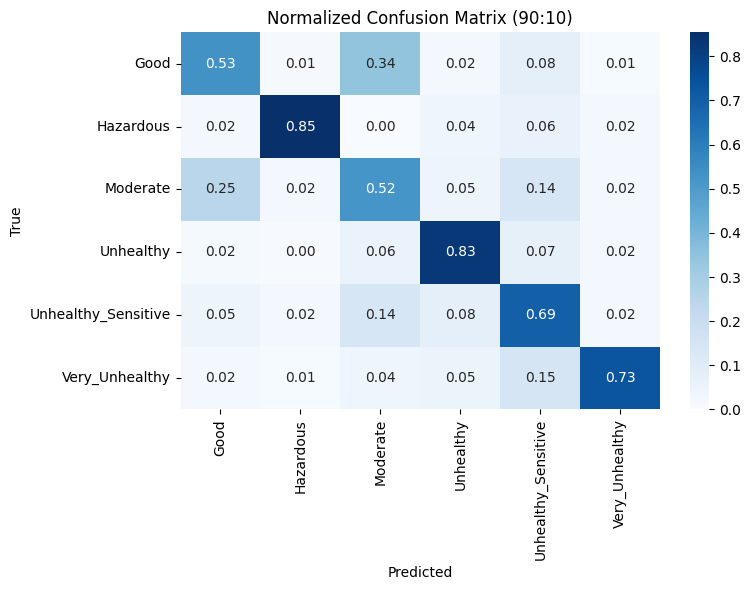

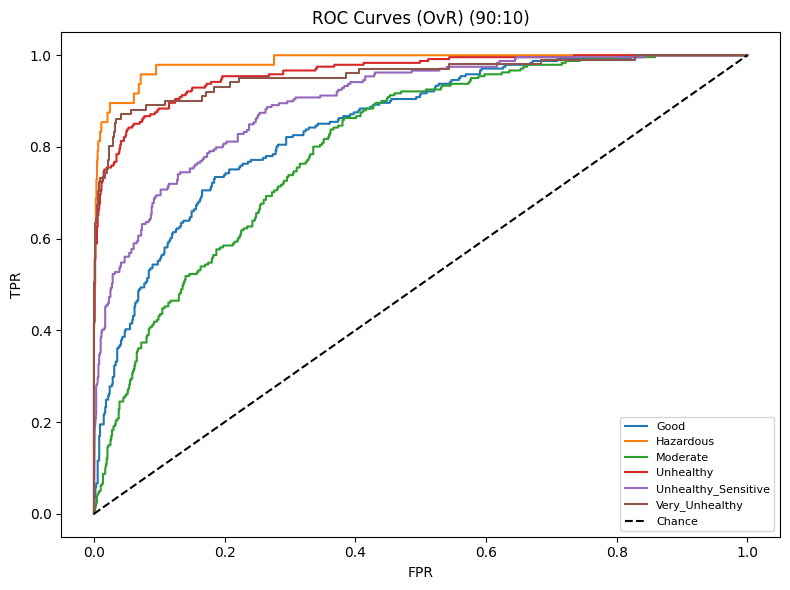


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.34
            Moderate → Good               : 0.25
      Very_Unhealthy → Unhealthy_Sensitive : 0.15
  Unhealthy_Sensitive → Moderate           : 0.14
            Moderate → Unhealthy_Sensitive : 0.14

[TEST] Ratio 80:20


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 1.717, Test Accuracy: 0.652
Total Test Time: 16.54 seconds for 2221 images
Average Inference Time per Image: 0.007447 s (~7.45 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.697095
1            Hazardous  0.718750
2             Moderate  0.423237
3            Unhealthy  0.802495
4  Unhealthy_Sensitive  0.624217
5       Very_Unhealthy  0.761194

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5201    0.6971    0.5957       482
          Hazardous     0.8734    0.7188    0.7886        96
           Moderate     0.5037    0.4232    0.4600       482
          Unhealthy     0.8195    0.8025    0.8109       481
Unhealthy_Sensitive     0.7052    0.6242    0.6622       479
     Very_Unhealthy     0.7806    0.7612    0.7708       201

           accuracy                         0.6515      2221
          macro avg     0.7004    0.6712    0.6814      2221
       weighted avg     

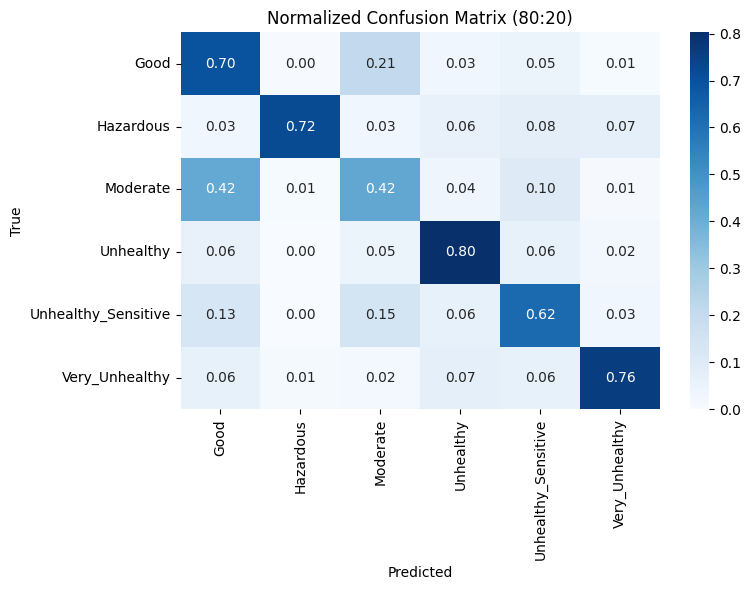

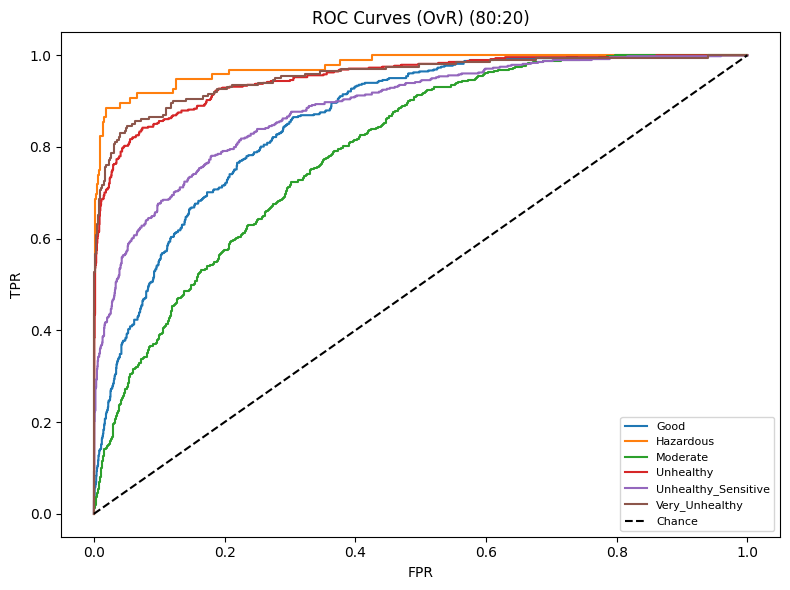


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.42
                Good → Moderate           : 0.21
  Unhealthy_Sensitive → Moderate           : 0.15
  Unhealthy_Sensitive → Good               : 0.13
            Moderate → Unhealthy_Sensitive : 0.10

[TEST] Ratio 70:30


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 2.127, Test Accuracy: 0.647
Total Test Time: 24.71 seconds for 3331 images
Average Inference Time per Image: 0.007418 s (~7.42 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.618257
1            Hazardous  0.763889
2             Moderate  0.457064
3            Unhealthy  0.786704
4  Unhealthy_Sensitive  0.653203
5       Very_Unhealthy  0.761589

Classification Report:

                     precision    recall  f1-score   support

               Good     0.6098    0.6183    0.6140       723
          Hazardous     0.7746    0.7639    0.7692       144
           Moderate     0.5069    0.4571    0.4807       722
          Unhealthy     0.7464    0.7867    0.7660       722
Unhealthy_Sensitive     0.6270    0.6532    0.6398       718
     Very_Unhealthy     0.7770    0.7616    0.7692       302

           accuracy                         0.6467      3331
          macro avg     0.6736    0.6735    0.6732      3331
       weighted avg     

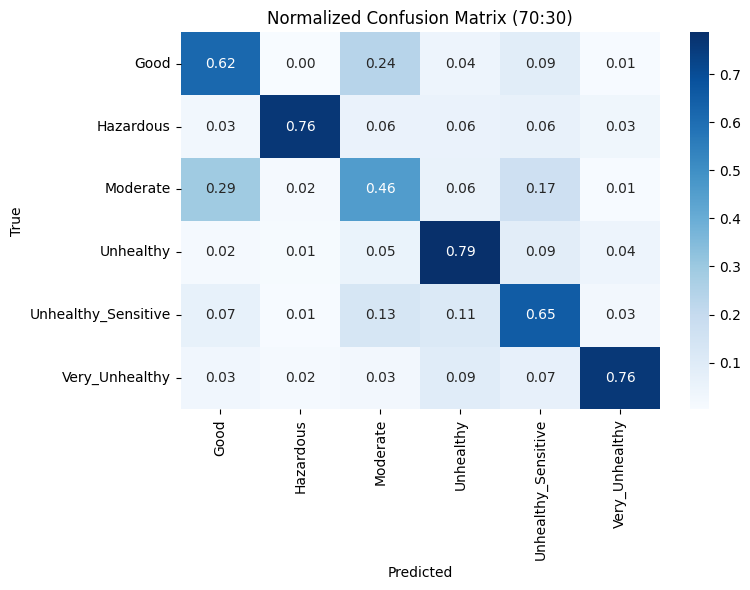

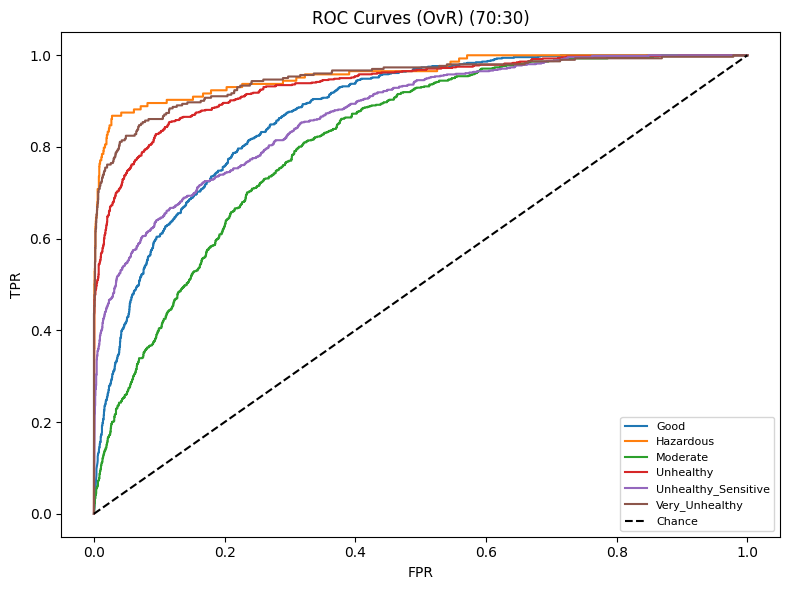


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.29
                Good → Moderate           : 0.24
            Moderate → Unhealthy_Sensitive : 0.17
  Unhealthy_Sensitive → Moderate           : 0.13
  Unhealthy_Sensitive → Unhealthy          : 0.11

[TEST] Ratio 60:40


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 1.902, Test Accuracy: 0.626
Total Test Time: 32.84 seconds for 4442 images
Average Inference Time per Image: 0.007393 s (~7.39 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.667705
1            Hazardous  0.751295
2             Moderate  0.447560
3            Unhealthy  0.755971
4  Unhealthy_Sensitive  0.551724
5       Very_Unhealthy  0.761787

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5206    0.6677    0.5851       963
          Hazardous     0.7143    0.7513    0.7323       193
           Moderate     0.4665    0.4476    0.4568       963
          Unhealthy     0.7862    0.7560    0.7708       963
Unhealthy_Sensitive     0.6718    0.5517    0.6059       957
     Very_Unhealthy     0.8342    0.7618    0.7964       403

           accuracy                         0.6263      4442
          macro avg     0.6656    0.6560    0.6579      4442
       weighted avg     

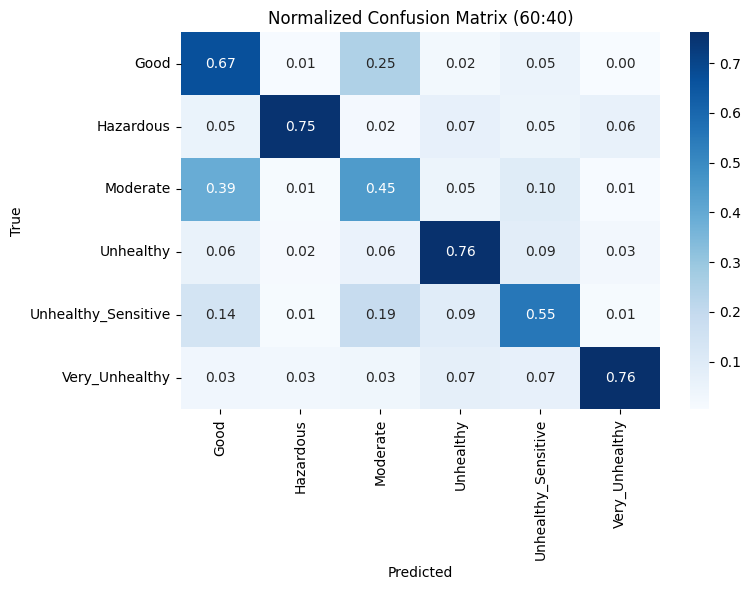

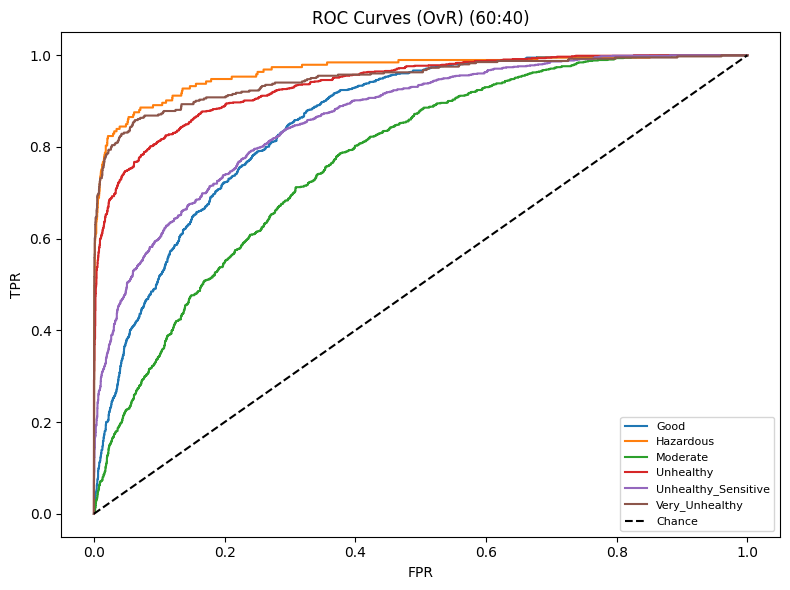


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.39
                Good → Moderate           : 0.25
  Unhealthy_Sensitive → Moderate           : 0.19
  Unhealthy_Sensitive → Good               : 0.14
            Moderate → Unhealthy_Sensitive : 0.10

[TEST] Ratio 50:50


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 1.907, Test Accuracy: 0.600
Total Test Time: 42.38 seconds for 5552 images
Average Inference Time per Image: 0.007633 s (~7.63 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.570598
1            Hazardous  0.658333
2             Moderate  0.400332
3            Unhealthy  0.718439
4  Unhealthy_Sensitive  0.647452
5       Very_Unhealthy  0.723658

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5793    0.5706    0.5749      1204
          Hazardous     0.6752    0.6583    0.6667       240
           Moderate     0.4635    0.4003    0.4296      1204
          Unhealthy     0.7594    0.7184    0.7384      1204
Unhealthy_Sensitive     0.5312    0.6475    0.5836      1197
     Very_Unhealthy     0.7368    0.7237    0.7302       503

           accuracy                         0.6000      5552
          macro avg     0.6242    0.6198    0.6205      5552
       weighted avg     

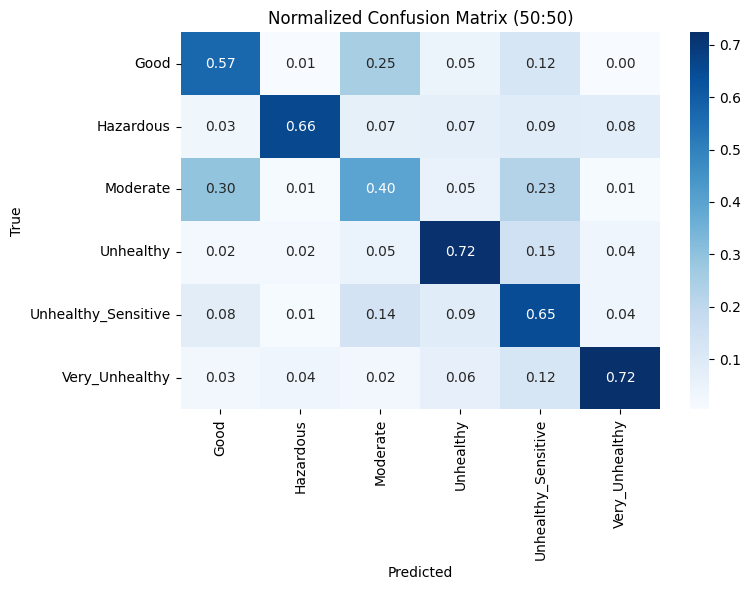

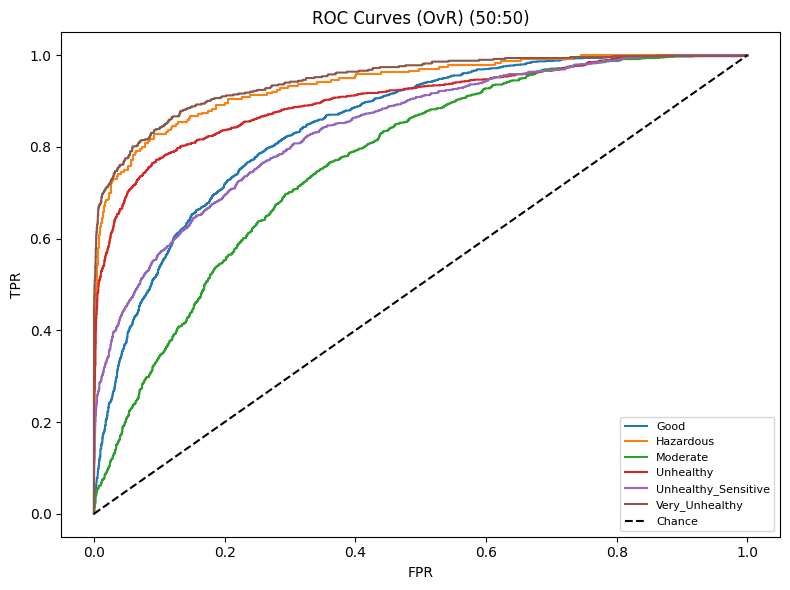


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.30
                Good → Moderate           : 0.25
            Moderate → Unhealthy_Sensitive : 0.23
           Unhealthy → Unhealthy_Sensitive : 0.15
  Unhealthy_Sensitive → Moderate           : 0.14

[TEST] Ratio 40:60


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 2.165, Test Accuracy: 0.570
Total Test Time: 48.69 seconds for 6662 images
Average Inference Time per Image: 0.007309 s (~7.31 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.716955
1            Hazardous  0.633218
2             Moderate  0.311634
3            Unhealthy  0.744460
4  Unhealthy_Sensitive  0.419916
5       Very_Unhealthy  0.741722

Classification Report:

                     precision    recall  f1-score   support

               Good     0.4679    0.7170    0.5663      1445
          Hazardous     0.6203    0.6332    0.6267       289
           Moderate     0.4241    0.3116    0.3593      1444
          Unhealthy     0.6821    0.7445    0.7119      1444
Unhealthy_Sensitive     0.7077    0.4199    0.5271      1436
     Very_Unhealthy     0.6747    0.7417    0.7066       604

           accuracy                         0.5696      6662
          macro avg     0.5962    0.5947    0.5830      6662
       weighted avg     

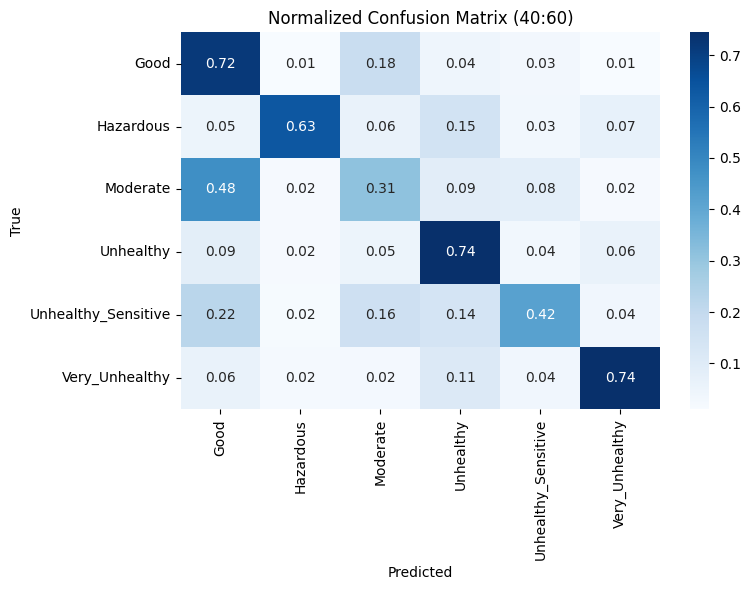

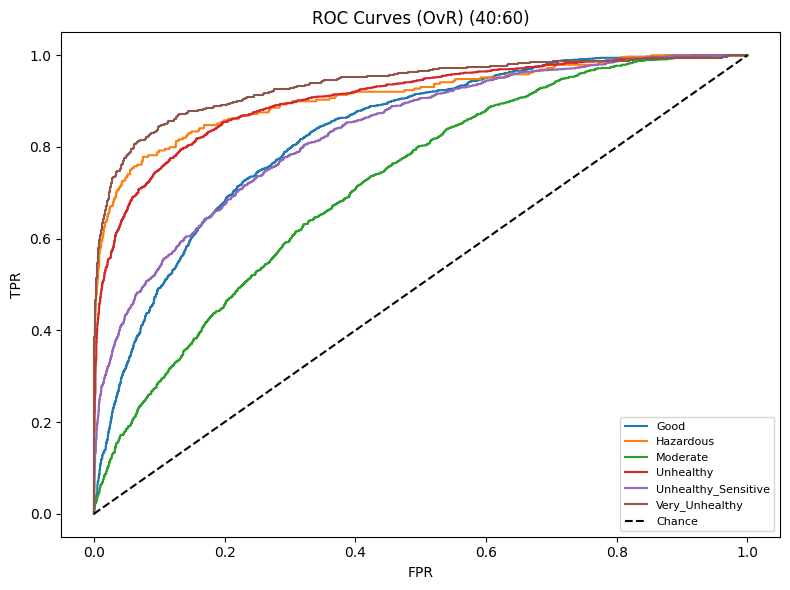


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.48
  Unhealthy_Sensitive → Good               : 0.22
                Good → Moderate           : 0.18
  Unhealthy_Sensitive → Moderate           : 0.16
           Hazardous → Unhealthy          : 0.15

[TEST] Ratio 30:70


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 2.713, Test Accuracy: 0.563
Total Test Time: 58.10 seconds for 7773 images
Average Inference Time per Image: 0.007474 s (~7.47 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.628707
1            Hazardous  0.427300
2             Moderate  0.382789
3            Unhealthy  0.757864
4  Unhealthy_Sensitive  0.509851
5       Very_Unhealthy  0.565957

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5183    0.6287    0.5682      1686
          Hazardous     0.8045    0.4273    0.5581       337
           Moderate     0.4180    0.3828    0.3996      1685
          Unhealthy     0.6095    0.7579    0.6757      1685
Unhealthy_Sensitive     0.5993    0.5099    0.5510      1675
     Very_Unhealthy     0.8210    0.5660    0.6700       705

           accuracy                         0.5634      7773
          macro avg     0.6284    0.5454    0.5704      7773
       weighted avg     

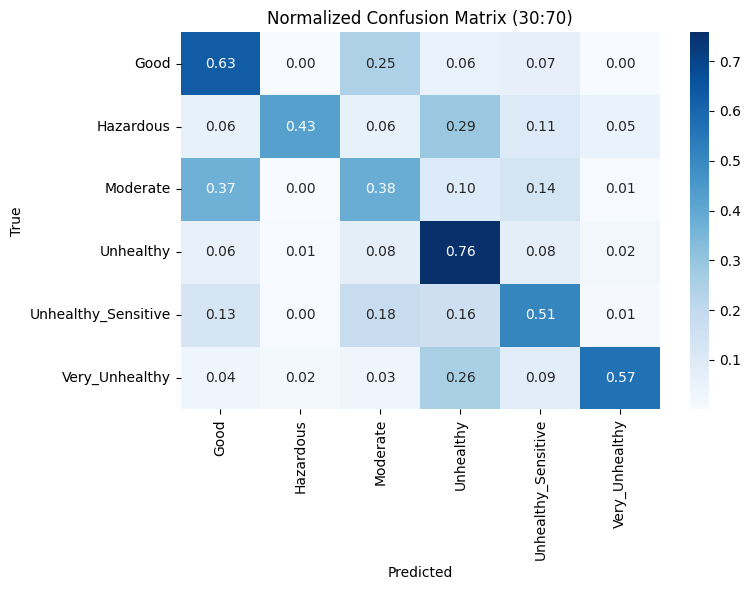

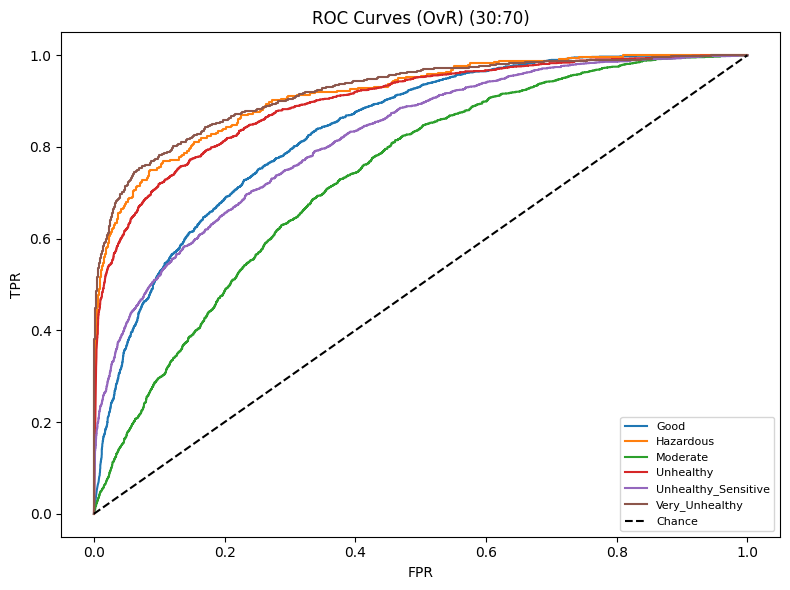


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.37
           Hazardous → Unhealthy          : 0.29
      Very_Unhealthy → Unhealthy          : 0.26
                Good → Moderate           : 0.25
  Unhealthy_Sensitive → Moderate           : 0.18

[TEST] Ratio 20:80


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 3.109, Test Accuracy: 0.532
Total Test Time: 67.13 seconds for 8883 images
Average Inference Time per Image: 0.007557 s (~7.56 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.423157
1            Hazardous  0.423377
2             Moderate  0.401869
3            Unhealthy  0.707165
4  Unhealthy_Sensitive  0.578892
5       Very_Unhealthy  0.626551

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5234    0.4232    0.4680      1926
          Hazardous     0.8069    0.4234    0.5554       385
           Moderate     0.4126    0.4019    0.4072      1926
          Unhealthy     0.6205    0.7072    0.6610      1926
Unhealthy_Sensitive     0.4935    0.5789    0.5328      1914
     Very_Unhealthy     0.6250    0.6266    0.6258       806

           accuracy                         0.5321      8883
          macro avg     0.5803    0.5268    0.5417      8883
       weighted avg     

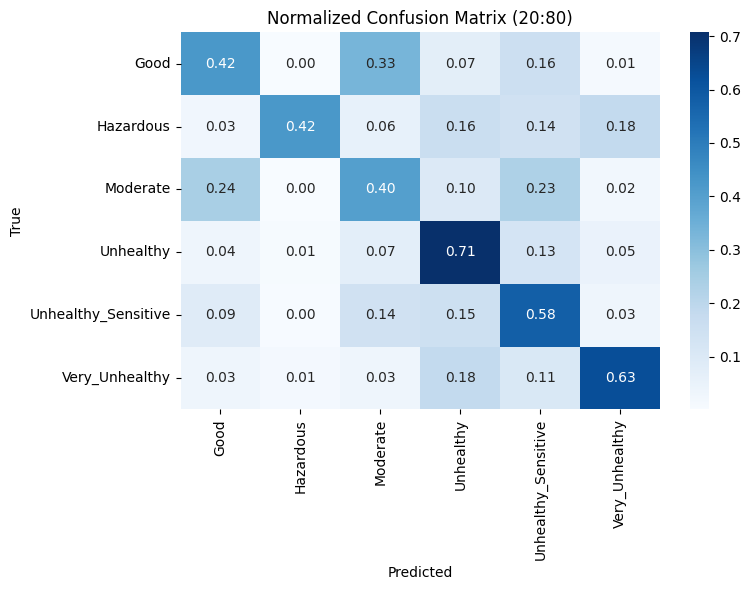

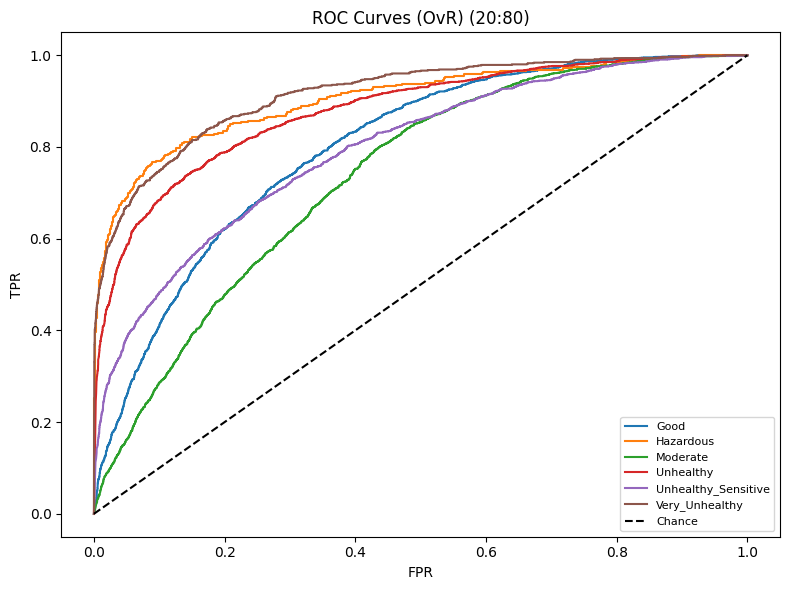


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.33
            Moderate → Good               : 0.24
            Moderate → Unhealthy_Sensitive : 0.23
      Very_Unhealthy → Unhealthy          : 0.18
           Hazardous → Very_Unhealthy     : 0.18

[TEST] Ratio 10:90


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Loss: 3.099, Test Accuracy: 0.466
Total Test Time: 73.75 seconds for 9993 images
Average Inference Time per Image: 0.007380 s (~7.38 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.529303
1            Hazardous  0.249423
2             Moderate  0.275035
3            Unhealthy  0.685596
4  Unhealthy_Sensitive  0.381616
5       Very_Unhealthy  0.550773

Classification Report:

                     precision    recall  f1-score   support

               Good     0.4925    0.5293    0.5102      2167
          Hazardous     0.5294    0.2494    0.3391       433
           Moderate     0.3601    0.2750    0.3119      2167
          Unhealthy     0.4729    0.6856    0.5597      2166
Unhealthy_Sensitive     0.4615    0.3816    0.4178      2154
     Very_Unhealthy     0.5645    0.5508    0.5575       906

           accuracy                         0.4660      9993
          macro avg     0.4802    0.4453    0.4494      9993
       weighted avg     

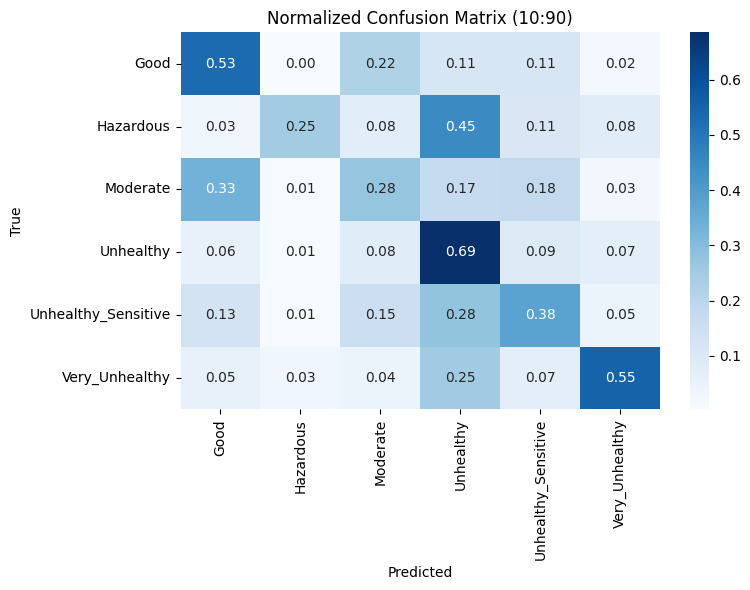

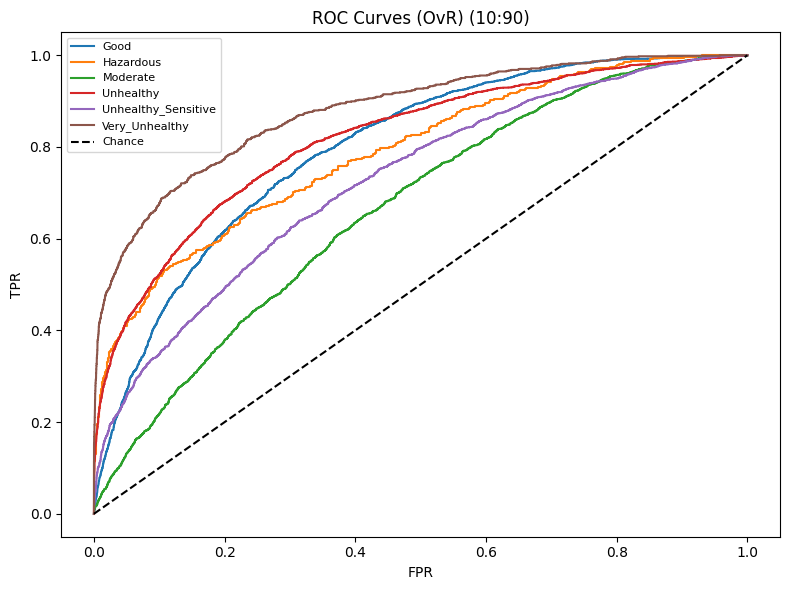


Top Confused Pairs (True → Pred, rate):
           Hazardous → Unhealthy          : 0.45
            Moderate → Good               : 0.33
  Unhealthy_Sensitive → Unhealthy          : 0.28
      Very_Unhealthy → Unhealthy          : 0.25
                Good → Moderate           : 0.22


In [22]:
import time
import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = sorted(df['label'].unique())
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}

for (tr, te) in RATIOS:
    print(f"\n[TEST] Ratio {tr}:{te}")
    save_path_checkpoints = os.path.join("/kaggle/working/task2_vgg16", f"{tr}_{te}")
    best_checkpoint_path = f"{save_path_checkpoints}/model.pt"

    # --- VGG16 model for testing ---
    model = models.vgg16(pretrained=True).to(device)
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, len(CLASS_NAMES))
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_weight"])

    split = SPLITS[(tr, te)]
    _, _, dataloader_test_dataset = data_transform(split["train_df"], split["valid_df"], split["test_df"])

    start_time = time.time()
    test_loss, test_accuracy, all_preds, all_labels, all_probs = evaluate_model(
        model, criterion, dataloader_test_dataset, return_preds=True
    )
    end_time = time.time()
    test_time = end_time - start_time
    n_test_images = len(split["test_df"])
    avg_inf_per_image_sec = test_time / n_test_images if n_test_images > 0 else float('nan')
    avg_inf_per_image_ms = avg_inf_per_image_sec * 1000.0

    print(f"Test Loss: {test_loss:.3f}, Test Accuracy: {test_accuracy:.3f}")
    print(f"Total Test Time: {test_time:.2f} seconds for {n_test_images} images")
    print(f"Average Inference Time per Image: {avg_inf_per_image_sec:.6f} s (~{avg_inf_per_image_ms:.2f} ms/image)")

    # ---- Everything below stays INSIDE the for-loop ----
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    per_class_acc_df = pd.DataFrame({'Class': CLASS_NAMES, 'Accuracy': per_class_acc})
    print("\nPer-Class Accuracy:")
    print(per_class_acc_df)

    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
    print("\nClassification Report:\n")
    print(report)

    y_true_bin = None
    try:
        y_true_bin = label_binarize(all_labels, classes=np.arange(len(CLASS_NAMES)))
        macro_auc = roc_auc_score(y_true_bin, all_probs, average='macro', multi_class='ovr')
    except Exception:
        macro_auc = np.nan
    print(f"Macro ROC–AUC (OvR): {macro_auc if not np.isnan(macro_auc) else 'NA'}")

    # ✅ FIXED: removed extra space before plt.figure
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Normalized Confusion Matrix ({tr}:{te})')
    cm_path = os.path.join(save_path_checkpoints, f'cm_norm_{tr}-{te}.png')
    plt.tight_layout()
    plt.savefig(cm_path)
    plt.show()

    try:
        if y_true_bin is not None:
            plt.figure(figsize=(8, 6))
            for i, cname in enumerate(CLASS_NAMES):
                fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
                plt.plot(fpr, tpr, label=cname)
            plt.plot([0, 1], [0, 1], 'k--', label='Chance')
            plt.xlabel('FPR')
            plt.ylabel('TPR')
            plt.title(f'ROC Curves (OvR) ({tr}:{te})')
            plt.legend(fontsize=8)
            roc_path = os.path.join(save_path_checkpoints, f'roc_{tr}-{te}.png')
            plt.tight_layout()
            plt.savefig(roc_path)
            plt.show()
    except Exception:
        pass

    cm_norm_off = cm_norm.copy()
    np.fill_diagonal(cm_norm_off, 0.0)
    confused = []
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            if i == j:
                continue
            confused.append((CLASS_NAMES[i], CLASS_NAMES[j], cm_norm_off[i, j]))
    confused.sort(key=lambda x: x[2], reverse=True)
    top_k = [c for c in confused if np.isfinite(c[2]) and c[2] > 0][:5]
    if top_k:
        print("\nTop Confused Pairs (True → Pred, rate):")
        for (t, p, r) in top_k:
            print(f"  {t:>18s} → {p:<18s} : {r:.2f}")
    else:
        print("\nNo significant confused pairs detected.")
